# Installing and importing needed modules

In [1]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 101.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
%pip -q install -U trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 10.6 MB/s eta 0:00:00


In [3]:
! pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 9.8 MB/s eta 0:00:00


In [4]:
# Standard library imports
import os
import random
import gc
from pathlib import Path

# Numerical / data tools
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

# HF datasets and models
from datasets import load_dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    BitsAndBytesConfig,
)
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

# Reproducibility: use the same seed each time
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
pd.set_option("display.max_colwidth", 180)

print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


In [5]:
import json

def load_jsonl(path):
    data = []
    with open(path, "r") as f:
        for line in f:
            data.append(json.loads(line))
    return data

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Mounting and loading all the parameters

In [7]:
# Global configuration
SFT_MODEL = "google/gemma-3-1b-it"



SFT_DATASET = load_jsonl("/content/processed_stories_1.jsonl")
print(len(SFT_DATASET))

SFT_MAX_LENGTH = 1024

SFT_EPOCHS_LORA = 1

BASE_OUTPUT_DIR = Path("Outputs")
BASE_OUTPUT_DIR.mkdir(exist_ok=True)

# LoRA settings

SFT_LORA_R = 16
SFT_LORA_ALPHA = 16
SFT_LORA_DROPOUT = 0.10
#SFT_LORA_TARGETS = ["q_proj", "v_proj"]
SFT_LORA_TARGETS = ["self_attn.q_proj", "self_attn.v_proj"]

709


In [8]:
# helper functions

def count_trainable_params(model):
    """Return trainable params, total params, and trainable percentage."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    pct = 100 * trainable / total
    return trainable, total, pct


def summarize_trainable_params(model, label="model"):
    """Print and return a compact parameter summary for easy comparison."""
    trainable, total, pct = count_trainable_params(model)
    print(f"{label}: trainable={trainable:,} | total={total:,} | trainable%={pct:.2f}")
    return {
        "trainable_params": trainable,
        "total_params": total,
        "trainable_pct": pct,
    }


def history_df(trainer):
    """Turn a Trainer/SFTTrainer log history into a DataFrame."""
    return pd.DataFrame(trainer.state.log_history)


def epoch_history_table(trainer, columns=None):
    """Show only the most useful training/eval columns."""
    hist = history_df(trainer)
    if hist.empty:
        return hist
    if columns is None:
        columns = [
            "epoch", "loss", "eval_loss", "eval_accuracy", "eval_macro_f1",
            "learning_rate", "grad_norm", "mean_token_accuracy"
        ]
    cols = [c for c in columns if c in hist.columns]
    if not cols:
        return hist
    metric_cols = [c for c in cols if c != "epoch"]
    table = hist.dropna(subset=metric_cols, how="all").copy()
    if table.empty:
        table = hist.copy()
    return table[cols].reset_index(drop=True)


def last_logged_metrics(trainer, prefix="eval_"):
    """Grab the last logged evaluation metrics from the trainer history."""
    hist = history_df(trainer)
    if hist.empty:
        return {}
    cols = [c for c in hist.columns if c.startswith(prefix)]
    if not cols:
        return {}
    rows = hist.dropna(subset=cols, how="all")
    if rows.empty:
        return {}
    last = rows.iloc[-1]
    return {c: last[c] for c in cols if pd.notna(last[c])}


def remove_notebook_progress_callback(trainer):
    """Avoid notebook callback issues before calling predict()."""
    try:
        from transformers.utils.notebook import NotebookProgressCallback
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass


def cleanup(*objs):
    """Free memory between large runs."""
    for obj in objs:
        del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Train / Test / Val Data split

In [9]:
# Load and split the Alpaca-style dataset.
# We shuffle first, then split into train/validation/test sets.
from datasets import Dataset # Import Dataset class

# Create a Dataset from the loaded list of dictionaries
raw_sft = Dataset.from_list(SFT_DATASET)
print(raw_sft)
print(raw_sft[0])

sft_shuffled = raw_sft.shuffle(seed=SEED)

# Correctly split the dataset into train, validation, and test sets
total_size = len(sft_shuffled)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size # Ensure all samples are used

sft_ds = DatasetDict({
    "train": sft_shuffled.select(range(0, train_size)),
    "validation": sft_shuffled.select(range(train_size, train_size + val_size)),
    "test": sft_shuffled.select(range(train_size + val_size, total_size)),
})

print(sft_ds)

Dataset({
    features: ['text'],
    num_rows: 709
})
{'text': "<GENRE> fantasy\n\n<PROMPT>\n[ WP ] The Last Person On Earth\n\n<STORY>\nThe sun seeping in through the dusty , curtained windows finally draws me out of sleep . Most days I am awake before now , most days I am a scavenger of civilization 's decay , the last lonely nomad . Most days I am not bedridden . Most days I do not make such foolish mistakes . It was foolish of me , to go leaping up the tree like that . It would have been just as foolish to stay on the ground though . \n \n The dogs have gotten out of control . Man 's best friend . Yeah fucking right . The dogs have forgotten man , just as quickly as everything else did . The Dobermans , St. Bernards and even the Labradors grew feral more quickly that I would have imagined . The Chihuahuas and Toy Poodles died off without their over protective mothers to watch them . \n \n For years I have carried a gun with me , though I try to shoot as few of them as I might . Ev

# Loading secret Hugging_face token

In [10]:
from google.colab import userdata
from huggingface_hub import login

token = userdata.get('HF_TOKEN')
login(token)

# Formatting the Data like prompt and loading the Tokenizer

In [11]:
# Format prompt-completion pairs for SFTTrainer.
# The prompt contains the instruction (and input if present).
# The completion is the target response the model should learn to generate.

# Tokenizer and prompt suite for side-by-side generation comparisons.
# The prompt suite is small on purpose so you can inspect outputs directly.
sft_tokenizer = AutoTokenizer.from_pretrained(SFT_MODEL, use_fast=True)
if sft_tokenizer.pad_token is None:
    sft_tokenizer.pad_token = sft_tokenizer.eos_token

EOS_TOKEN = sft_tokenizer.eos_token

def alpaca_prompt(entry):
  text = entry["text"]

  genre = text.split("<GENRE>")[1].split("<PROMPT>")[0].strip()
  prompt = text.split("<PROMPT>")[1].split("<STORY>")[0].strip()
  story = text.split("<STORY>")[1].strip()

  return f"""### Instruction:

  You are a professional story writer.
  Write a complete, engaging {genre} short story.

  Requirements:
  - Story must be 1 - 2 paragraphs
  - Clear beginning, middle, and ending
  - No repetition
  - Strong narrative flow

### Story idea:
{prompt}

### Story:
"""

def clean_short_story(story, max_paragraphs=2, max_tokens=850):
    paragraphs = [p.strip() for p in story.split("\n\n") if p.strip()]
    story = "\n\n".join(paragraphs[:max_paragraphs])

    ids = sft_tokenizer(
        story,
        truncation=True,
        max_length=max_tokens,
        add_special_tokens=False
    )["input_ids"]

    return sft_tokenizer.decode(ids, skip_special_tokens=True).strip()


def to_prompt_completion(entry):
  text = entry["text"]
  story = text.split("<STORY>")[1].strip()
  story = clean_short_story(story, max_paragraphs=2, max_tokens=850)
  return {
        "prompt": alpaca_prompt(entry),
        "completion": story + EOS_TOKEN,
    }



sft_pc = sft_ds.map(to_prompt_completion, remove_columns=sft_ds["train"].column_names)
print(sft_pc["train"][0])
print()
print(sft_pc["train"][1])

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

Map:   0%|          | 0/567 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

Map:   0%|          | 0/72 [00:00<?, ? examples/s]

{'prompt': '### Instruction:\n\n  You are a professional story writer.\n  Write a complete, engaging romance short story.\n\n  Requirements:\n  - Story must be 1 - 2 paragraphs\n  - Clear beginning, middle, and ending\n  - No repetition\n  - Strong narrative flow\n\n### Story idea:\n[ CW ] You have under 3 minutes to convince the love of your life to come back .\n\n### Story:\n', 'completion': "( So I 'm trying to write this in three minutes , forgive any misspellings or grammar ... Okay starting the timer ... . Now ! ) \n \n \n `` Baby please wait ! '' I ran after her trying to catch up . I love her , I just need her to see it . \n \n \n She turned around and stared daggers at me , `` Fine , you 've got two minutes to convince me to stay . That 's it . Then I 'm leaving for good . '' \n \n \n Okay uh where to start ? \n \n \n `` A minute and fifty seconds . '' \n \n \n `` I do n't need you in my life . You could leave today and I would go on with- '' \n \n \n `` You are n't helping he

In [12]:
sample = sft_pc["train"][0]["prompt"] + sft_pc["train"][0]["completion"]
ids = sft_tokenizer(sample)["input_ids"]

print("EOS ID:", sft_tokenizer.eos_token_id)
print("Last token ID:", ids[-1])
print("Ends with EOS:", ids[-1] == sft_tokenizer.eos_token_id)

EOS ID: 1
Last token ID: 1
Ends with EOS: True


In [13]:
sample = sft_pc["train"][0]

print("Prompt preview:")
print(sample["prompt"][-300:])

print("\nCompletion ending:")
print(repr(sample["completion"][-100:]))

Prompt preview:
er.
  Write a complete, engaging romance short story.

  Requirements:
  - Story must be 1 - 2 paragraphs
  - Clear beginning, middle, and ending
  - No repetition
  - Strong narrative flow

### Story idea:
[ CW ] You have under 3 minutes to convince the love of your life to come back .

### Story:


Completion ending:
"ll those nights when I was n't in bed worrying about the right time to ask you to marry me . ''<eos>"


In [14]:
for i in range(5):
    print("=" * 100)
    print(sft_pc["train"][i]["completion"])

( So I 'm trying to write this in three minutes , forgive any misspellings or grammar ... Okay starting the timer ... . Now ! ) 
 
 
 `` Baby please wait ! '' I ran after her trying to catch up . I love her , I just need her to see it . 
 
 
 She turned around and stared daggers at me , `` Fine , you 've got two minutes to convince me to stay . That 's it . Then I 'm leaving for good . '' 
 
 
 Okay uh where to start ? 
 
 
 `` A minute and fifty seconds . '' 
 
 
 `` I do n't need you in my life . You could leave today and I would go on with- '' 
 
 
 `` You are n't helping here . '' 
 
 
 `` Wait , I have a minute , let me finish please . I do n't need you , if you left today I would go on , through the motions , maybe someday find a nice girl who made me happy . But she would n't be you , I do n't want another girl , I do n't want anything else in my life , I want you . I want to spend everyday for the rest of my life trying to prove to the world that I am good enough for you . I kn

In [15]:
full_lengths = []

for ex in sft_pc["train"]:
    full_text = ex["prompt"] + ex["completion"]
    ids = sft_tokenizer(full_text)["input_ids"]
    full_lengths.append(len(ids))

import pandas as pd

print(pd.Series(full_lengths).describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))
print("SFT_MAX_LENGTH:", SFT_MAX_LENGTH)

count    567.000000
mean     689.777778
std      194.679713
min      319.000000
50%      678.000000
75%      883.500000
90%      954.400000
95%      969.000000
99%      983.680000
max      997.000000
dtype: float64
SFT_MAX_LENGTH: 1024


In [16]:
PROMPT_SUITE = [sft_pc["test"][i]["prompt"] for i in range(min(6, len(sft_pc["test"]))) ]
REFERENCE_COMPLETIONS = [sft_pc["test"][i]["completion"] for i in range(min(6, len(sft_pc["test"]))) ]


def generate_responses(model, tokenizer, prompts, max_new_tokens=300):
    """Generate deterministic outputs for a small list of prompts."""
    model.eval()
    outputs = []
    device = next(model.parameters()).device
    for prompt in prompts:
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=SFT_MAX_LENGTH).to(device)
        with torch.no_grad():
            gen = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                repetition_penalty=1.2,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
        decoded = tokenizer.decode(gen[0], skip_special_tokens=True)
        outputs.append(decoded[len(prompt):].strip() if decoded.startswith(prompt) else decoded.strip())
    return outputs

# Base model Generation

In [17]:
base_sft_model = AutoModelForCausalLM.from_pretrained(SFT_MODEL)
base_sft_model.resize_token_embeddings(len(sft_tokenizer))
if getattr(base_sft_model.config, "pad_token_id", None) is None:
    base_sft_model.config.pad_token_id = sft_tokenizer.pad_token_id
base_sft_model.to(DEVICE)

base_outputs = generate_responses(base_sft_model, sft_tokenizer, PROMPT_SUITE)

display(pd.DataFrame({
    "prompt": PROMPT_SUITE,
    "base_output": base_outputs,
    "reference_completion": REFERENCE_COMPLETIONS,
}))

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


,prompt,base_output,reference_completion
0,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging fantasy short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","The air hung thick with the scent of lavender and something else…something metallic. It was always like this when I arrived – a subtle tang that clung to my wings, marking me a...","Sometimes it gets messy . It can be a messy job , but someone has to do it . I ’ m the guy who makes the mess , not the one who cleans it up . \n \n It ’ s the same old story ...."
1,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging romance short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","The crimson dust swirled around my boots as I surveyed the alien landscape. The twin suns cast long, distorted shadows across jagged peaks that pierced the ochre sky. It was br...","`` Sure Sam , sign up for the first race on a new planet . They 'll never find out who you are when you win . No , and man when they get to the top of the mountain it wo n't re..."
2,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging sci-fi short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear b...","The shimmer started subtly – a heat haze above Mars’s northern plains, quickly escalating into an iridescent distortion of light. Then came the ships. Not sleek, silver vessels...","Paraded in front of millions , berrated and yelled at . No one understood my refusal to go with them into space . I had never told anyone what had happened in that room . Even ..."
3,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging romance short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","The rain hammered against the windows of Blackwood Manor, mirroring the tempest inside me. I'd come here seeking solace, a temporary escape from the ghosts that haunted my pas...","I love you ! \n \n Your taste is beyond all compare \n \n Crisper than apple , sweeter than pear \n \n Hard on the surface , but soft deep within \n \n Brighter and better than..."
4,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging romance short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","The bell above the door of ""Rosie's Diner"" chimed as Amelia arrived each morning, her worn denim jacket pulled tight against the chill of the early autumn air. She’d been comin...","The city was colder than usual . William squinted as he trudged through the frozen fog . Far in the distance , at the end of the block , he saw the lights of the diner . As he ..."
5,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging romance short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","The rain hammered against the windows of The Crimson Quill bookstore, mirroring the frantic rhythm of my heart as I watched him. He was leaning against a towering shelf filled ...","As of today it 's been five years , five months , and three days since I last saw you alive . I was n't allowed to attend your funeral service . Family said it would be a disgr..."


In [18]:
import math
from tqdm import tqdm

def compute_loss_and_perplexity(model, tokenizer, eval_texts, max_length=1024):
    model.eval()
    losses = []

    for text in tqdm(eval_texts):
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=max_length
        ).to(model.device)

        with torch.no_grad():
            outputs = model(
                **inputs,
                labels=inputs["input_ids"]
            )

        losses.append(outputs.loss.item())

    avg_loss = sum(losses) / len(losses)
    perplexity = math.exp(avg_loss)

    return avg_loss, perplexity

In [19]:
N_PER_GENRE = 10

def extract_genre_from_prompt(prompt):
    p = prompt.lower()

    if "fantasy short story" in p:
        return "fantasy"
    if "sci-fi short story" in p or "science fiction short story" in p:
        return "sci-fi"
    if "romance short story" in p:
        return "romance"

    return "unknown"


test_rows = []

for ex in sft_pc["test"]:
    genre = extract_genre_from_prompt(ex["prompt"])

    if genre != "unknown":
        test_rows.append({
            "prompt": ex["prompt"],
            "reference_completion": ex["completion"],
            "genre": genre
        })

test_df = pd.DataFrame(test_rows)

eval_sample_df = (
    test_df
    .groupby("genre", group_keys=False)
    .apply(lambda x: x.sample(n=min(N_PER_GENRE, len(x)), random_state=SEED))
    .reset_index(drop=True)
)

print(eval_sample_df["genre"].value_counts())
display(eval_sample_df.head())

genre
fantasy    10
romance    10
sci-fi     10
Name: count, dtype: int64


/tmp/ipykernel_8315/2518288413.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(N_PER_GENRE, len(x)), random_state=SEED))


,prompt,reference_completion,genre
0,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging fantasy short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","3546 BC . That was the time the attractive agent had entered into the machine . Professor Jonah Koslov , having been selected by the UN in a private meeting as the best candida...",fantasy
1,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging fantasy short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...",`` Welcome to the Afterlife '' A disembodied female voice spoke . \n \n `` Huh ? '' Zack said confused . He scanned the room he was in . It was an empty room with a door on eac...,fantasy
2,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging fantasy short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","They told me to clean the house because I was the one who was closest to my late grandfather . In the twilight of his life , it had been I who had stayed loyally by his side , ...",fantasy
3,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging fantasy short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","It 's just a timeline , but if figured timelines can also be stories . \n \n -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- - \n \n November 8 , 2020 : Despite 4 years r...",fantasy
4,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging fantasy short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","I continue to beat the fucker 's head until the life has vacated his eyes , then carry on to the point in which there was almost nothing left . I stop when the baseball bat cle...",fantasy


In [20]:
eval_texts = eval_sample_df["prompt"].tolist()

In [21]:
base_loss, base_ppl = compute_loss_and_perplexity(
    base_sft_model,
    sft_tokenizer,
    eval_texts
)

100%|██████████| 30/30 [00:04<00:00,  6.79it/s]


In [22]:
metrics_table = pd.DataFrame([
    {
         "System": "Base Gemma-3-1B-it",
         "Adaptation": "None",
         "Evaluation Set": "Same held-out evaluation set",
         "Validation Loss": base_loss,
         "Perplexity": base_ppl
     }
])

In [23]:
import os
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [24]:
metrics_table.to_csv(RESULTS_DIR / "metrics_basemodel.csv", index=False)

display(metrics_table)

,System,Adaptation,Evaluation Set,Validation Loss,Perplexity
0,Base Gemma-3-1B-it,None,Same held-out evaluation set,3.826757,45.913409


In [25]:
del base_sft_model
import gc, torch
gc.collect()
torch.cuda.empty_cache()

# Loading and building QLoRA setup

In [26]:
# ---------------------------------------------------
# 1) 4-bit NormalFloat (NF4) + 2) Double Quantization
# ---------------------------------------------------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",          # NF4
    bnb_4bit_use_double_quant=True,     # Double quantization
    bnb_4bit_compute_dtype=torch.bfloat16
)

In [27]:
sft_results = {}

sft_lora_base = AutoModelForCausalLM.from_pretrained(
    SFT_MODEL,
    quantization_config=bnb_config,
    device_map={"": "cpu"},
    torch_dtype=torch.bfloat16, # bfloat16 to save memory
)

# Prepare quantized model for k-bit training
sft_lora_base.gradient_checkpointing_enable()
sft_lora_base.config.use_cache = False
sft_lora_base = prepare_model_for_kbit_training(sft_lora_base)

# THEN move to GPU
sft_lora_base = sft_lora_base.to("cuda")

sft_lora_base.resize_token_embeddings(len(sft_tokenizer))
if getattr(sft_lora_base.config, "pad_token_id", None) is None:
    sft_lora_base.config.pad_token_id = sft_tokenizer.pad_token_id

# Build exact LoRA targets only from the language model
lm_target_modules = [
    name for name, _ in sft_lora_base.named_modules()
    if "self_attn.q_proj" in name or "self_attn.v_proj" in name
]

print("Sample targets:", lm_target_modules[:6])
print("Total targets:", len(lm_target_modules))

# LoRA config for causal LM fine-tuning.
sft_lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=SFT_LORA_R,
    lora_alpha=SFT_LORA_ALPHA,
    lora_dropout=SFT_LORA_DROPOUT,
    target_modules=lm_target_modules,
)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Sample targets: ['model.layers.0.self_attn.q_proj', 'model.layers.0.self_attn.v_proj', 'model.layers.1.self_attn.q_proj', 'model.layers.1.self_attn.v_proj', 'model.layers.2.self_attn.q_proj', 'model.layers.2.self_attn.v_proj']
Total targets: 52


In [28]:
print("Total targets:", len(lm_target_modules))

for name, module in sft_lora_base.named_modules():
    if "q_proj" in name:
        print(name, type(module))

Total targets: 52
model.layers.0.self_attn.q_proj <class 'bitsandbytes.nn.modules.Linear4bit'>
model.layers.1.self_attn.q_proj <class 'bitsandbytes.nn.modules.Linear4bit'>
model.layers.2.self_attn.q_proj <class 'bitsandbytes.nn.modules.Linear4bit'>
model.layers.3.self_attn.q_proj <class 'bitsandbytes.nn.modules.Linear4bit'>
model.layers.4.self_attn.q_proj <class 'bitsandbytes.nn.modules.Linear4bit'>
model.layers.5.self_attn.q_proj <class 'bitsandbytes.nn.modules.Linear4bit'>
model.layers.6.self_attn.q_proj <class 'bitsandbytes.nn.modules.Linear4bit'>
model.layers.7.self_attn.q_proj <class 'bitsandbytes.nn.modules.Linear4bit'>
model.layers.8.self_attn.q_proj <class 'bitsandbytes.nn.modules.Linear4bit'>
model.layers.9.self_attn.q_proj <class 'bitsandbytes.nn.modules.Linear4bit'>
model.layers.10.self_attn.q_proj <class 'bitsandbytes.nn.modules.Linear4bit'>
model.layers.11.self_attn.q_proj <class 'bitsandbytes.nn.modules.Linear4bit'>
model.layers.12.self_attn.q_proj <class 'bitsandbytes.nn

In [29]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.2 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [30]:
# ---- Probe ----
probe_model = AutoModelForCausalLM.from_pretrained(SFT_MODEL)
probe_model.resize_token_embeddings(len(sft_tokenizer))

if getattr(probe_model.config, "pad_token_id", None) is None:
    probe_model.config.pad_token_id = sft_tokenizer.pad_token_id


sft_lora_probe = get_peft_model(probe_model, sft_lora_config)


sft_results["lora"] = summarize_trainable_params(
    sft_lora_probe,
    label="Instruction SFT / LoRA (parameter check only)"
)
cleanup(sft_lora_probe)
cleanup(probe_model)


# ---- Wrap model manually ----
sft_lora_model = get_peft_model(sft_lora_base, sft_lora_config)


sft_lora_args = SFTConfig(
    output_dir=str(BASE_OUTPUT_DIR / "sft_qlora"),
    num_train_epochs=SFT_EPOCHS_LORA,
    learning_rate=5e-5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    logging_steps=20,
    logging_strategy="steps",
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    disable_tqdm=False,
    max_length=SFT_MAX_LENGTH,
    completion_only_loss=True,
    gradient_checkpointing=True,
    seed=SEED,

    optim="paged_adamw_32bit",
)



# ---- Trainer ----
sft_lora_trainer = SFTTrainer(
    model=sft_lora_model,
    args=sft_lora_args,
    train_dataset=sft_pc["train"],
    eval_dataset=sft_pc["validation"],
    processing_class=sft_tokenizer,
)

# Recompute params on the actual wrapped model used by the trainer.
sft_results["lora"] = summarize_trainable_params(sft_lora_trainer.model, label="Instruction SFT / LoRA")

sft_lora_train_output = sft_lora_trainer.train()
remove_notebook_progress_callback(sft_lora_trainer)

sft_lora_eval = last_logged_metrics(sft_lora_trainer)
sft_results["lora"].update({
    "train_runtime": sft_lora_train_output.metrics.get("train_runtime"),
    **sft_lora_eval,
})

display(epoch_history_table(sft_lora_trainer, ["epoch", "loss", "eval_loss", "mean_token_accuracy", "learning_rate", "grad_norm"]))
display(pd.DataFrame([sft_results["lora"]])[[
    "trainable_params", "total_params", "trainable_pct", "train_runtime", "eval_loss"
]].round(4))

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Instruction SFT / LoRA (parameter check only): trainable=1,490,944 | total=1,001,378,048 | trainable%=0.15


Adding EOS to train dataset:   0%|          | 0/567 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/567 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/70 [00:00<?, ? examples/s]

...

Instruction SFT / LoRA: trainable=1,490,944 | total=652,497,152 | trainable%=0.23


Epoch,Training Loss,Validation Loss
1,3.212832,3.289875


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:386: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


,epoch,loss,eval_loss,mean_token_accuracy,learning_rate,grad_norm
0,0.141093,3.703166,NaN,0.338067,0.000043,1.234375
1,0.282187,3.412159,NaN,0.364026,0.000036,0.738281
2,0.423280,3.414476,NaN,0.367480,0.000029,0.578125
3,0.564374,3.306686,NaN,0.383297,0.000022,0.617188
4,0.705467,3.301996,NaN,0.381463,0.000015,0.554688
5,0.846561,3.251136,NaN,0.391437,0.000008,0.431641
6,0.987654,3.212832,NaN,0.400151,0.000001,0.472656
7,1.000000,NaN,3.289875,NaN,NaN,NaN


,trainable_params,total_params,trainable_pct,train_runtime,eval_loss
0,1490944,652497152,0.2285,1463.4387,3.2899


In [31]:
display(epoch_history_table(sft_lora_trainer, ["epoch", "loss", "eval_loss", "mean_token_accuracy", "learning_rate", "grad_norm"]))
display(pd.DataFrame([sft_results["lora"]])[[
    "trainable_params", "total_params", "trainable_pct", "train_runtime", "eval_loss"
]].round(4))

,epoch,loss,eval_loss,mean_token_accuracy,learning_rate,grad_norm
0,0.141093,3.703166,NaN,0.338067,0.000043,1.234375
1,0.282187,3.412159,NaN,0.364026,0.000036,0.738281
2,0.423280,3.414476,NaN,0.367480,0.000029,0.578125
3,0.564374,3.306686,NaN,0.383297,0.000022,0.617188
4,0.705467,3.301996,NaN,0.381463,0.000015,0.554688
5,0.846561,3.251136,NaN,0.391437,0.000008,0.431641
6,0.987654,3.212832,NaN,0.400151,0.000001,0.472656
7,1.000000,NaN,3.289875,NaN,NaN,NaN


,trainable_params,total_params,trainable_pct,train_runtime,eval_loss
0,1490944,652497152,0.2285,1463.4387,3.2899


In [32]:
import os
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Save complete trainer log history
training_logs_df = pd.DataFrame(sft_lora_trainer.state.log_history)
training_logs_df.to_csv(RESULTS_DIR / "training_logs.csv", index=False)

print("Saved training logs to:", RESULTS_DIR / "training_logs.csv")
display(training_logs_df.tail())

Saved training logs to: results/training_logs.csv


,loss,grad_norm,learning_rate,entropy,num_tokens,mean_token_accuracy,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,eval_entropy,eval_num_tokens,eval_mean_token_accuracy,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
4,3.301996,0.554688,0.000015,2.874121,277539.0,0.381463,0.705467,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3.251136,0.431641,0.000008,2.852757,331233.0,0.391437,0.846561,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,3.212832,0.472656,0.000001,2.813384,386779.0,0.400151,0.987654,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,142,3.289875,57.847,1.21,1.21,2.855235,391104.0,0.389958,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1463.4387,0.387,0.097,1.641198e+15,3.372343


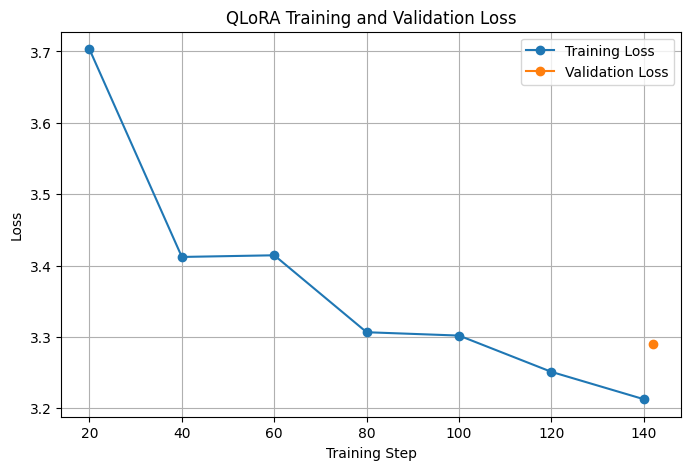

Saved loss curve to: results/loss_curve.png


In [33]:
import matplotlib.pyplot as plt

log_df = pd.DataFrame(sft_lora_trainer.state.log_history)

# Training loss rows
train_loss_df = log_df[log_df["loss"].notna()] if "loss" in log_df.columns else pd.DataFrame()

# Eval loss rows
eval_loss_df = log_df[log_df["eval_loss"].notna()] if "eval_loss" in log_df.columns else pd.DataFrame()

plt.figure(figsize=(8, 5))

if not train_loss_df.empty:
    plt.plot(train_loss_df["step"], train_loss_df["loss"], marker="o", label="Training Loss")

if not eval_loss_df.empty:
    plt.plot(eval_loss_df["step"], eval_loss_df["eval_loss"], marker="o", label="Validation Loss")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("QLoRA Training and Validation Loss")
plt.legend()
plt.grid(True)

loss_curve_path = RESULTS_DIR / "loss_curve.png"
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved loss curve to:", loss_curve_path)

In [34]:
lora_outputs = generate_responses(sft_lora_model, sft_tokenizer, PROMPT_SUITE)

display(pd.DataFrame({
    "prompt": PROMPT_SUITE,
    "sft_lora": lora_outputs,
    "reference_completion": REFERENCE_COMPLETIONS,
}))

,prompt,sft_lora,reference_completion
0,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging fantasy short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...",The air hung thick with the scent of lavender and something faintly metallic – like old pennies. Little Leo’s room was a whirlwind of mismatched blankets and scattered LEGO bri...,"Sometimes it gets messy . It can be a messy job , but someone has to do it . I ’ m the guy who makes the mess , not the one who cleans it up . \n \n It ’ s the same old story ...."
1,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging romance short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...",**The Echoes of Xylos**\n\n\nI made this picture of a person on another planet . I do n’t know what the person in the picture is doing here . Perhaps you can fill me in ?\n\n\n...,"`` Sure Sam , sign up for the first race on a new planet . They 'll never find out who you are when you win . No , and man when they get to the top of the mountain it wo n't re..."
2,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging sci-fi short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear b...","The rain tasted like ash. It clung to my tongue, gritty and unwelcome. I stared at the swirling grey clouds above, each drop mirroring the blackness within me. The air hung thi...","Paraded in front of millions , berrated and yelled at . No one understood my refusal to go with them into space . I had never told anyone what had happened in that room . Even ..."
3,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging romance short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","I Love You <br>\nIt was the summer of my eighteenth birthday, as I stared out at the ocean with no one to see me, or anyone to hear me, but I smiled to myself as I thought ab...","I love you ! \n \n Your taste is beyond all compare \n \n Crisper than apple , sweeter than pear \n \n Hard on the surface , but soft deep within \n \n Brighter and better than..."
4,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging romance short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","---\nThe bell above the door of ""Rosie's Diner"" chimed as rain started falling again. The smell of burnt coffee and sizzling bacon filled the air. Leo had been sitting alone fo...","The city was colder than usual . William squinted as he trudged through the frozen fog . Far in the distance , at the end of the block , he saw the lights of the diner . As he ..."
5,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging romance short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","I am a professional storyteller who lives with the dreams of my past , and I've been helping people find their stories through writing. It seems like it’s going to get more dif...","As of today it 's been five years , five months , and three days since I last saw you alive . I was n't allowed to attend your funeral service . Family said it would be a disgr..."


In [35]:
def generate_debug(model, tokenizer, prompt, max_new_tokens=400):
    model.eval()
    device = next(model.parameters()).device

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=SFT_MAX_LENGTH
    ).to(device)

    with torch.no_grad():
        gen = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    decoded = tokenizer.decode(gen[0], skip_special_tokens=False)
    print(decoded)

generate_debug(sft_lora_model, sft_tokenizer, PROMPT_SUITE[0])

<bos>### Instruction:

  You are a professional story writer.
  Write a complete, engaging fantasy short story.

  Requirements:
  - Story must be 1 - 2 paragraphs
  - Clear beginning, middle, and ending
  - No repetition
  - Strong narrative flow

### Story idea:
[ WP ] You are the tooth fairy . Right as you are reaching underneath the child 's pillow , a parent walks in holding $ 5 .

### Story:
The rain hammered against the window of the small, cluttered house.  A young boy, no older than seven, sat curled up in a plush armchair, a half-finished jigsaw puzzle scattered around him.  He was engrossed in a world of colorful pieces, his brow furrowed in concentration.  Suddenly, a faint, shimmering light began to emanate from beneath the boy's pillow.  It wasn't a harsh glow, but a gentle, pearlescent luminescence, like moonlight filtered through silk.  The boy, startled, looked up, his eyes wide with a mixture of wonder and suspicion.  A tiny, perfectly formed tooth, crafted from iride

In [36]:
save_path = "/content/drive/MyDrive/sft_lora_model_v4"

sft_lora_model.save_pretrained(save_path)
sft_tokenizer.save_pretrained(save_path)

/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:386: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


('/content/drive/MyDrive/sft_lora_model_v4/tokenizer_config.json',
 '/content/drive/MyDrive/sft_lora_model_v4/chat_template.jinja',
 '/content/drive/MyDrive/sft_lora_model_v4/tokenizer.json')

In [37]:
import shutil
shutil.make_archive(save_path, 'zip', save_path)

'/content/drive/MyDrive/sft_lora_model_v4.zip'

# Evaluating the sample of results with a bigger LLM

In [38]:
lora_loss, lora_ppl = compute_loss_and_perplexity(
    sft_lora_model,
    sft_tokenizer,
    eval_texts
)

100%|██████████| 30/30 [00:06<00:00,  4.76it/s]


In [39]:
metrics_table = pd.DataFrame([
    {
        "System": "QLoRA-adapted Gemma-3-1B-it",
        "Adaptation": "QLoRA",
        "Evaluation Set": "Same held-out evaluation set",
        "Validation Loss": lora_loss,
        "Perplexity": lora_ppl
    }
])

metrics_table.to_csv(RESULTS_DIR / "metrics_QLoRA.csv", index=False)

display(metrics_table)

,System,Adaptation,Evaluation Set,Validation Loss,Perplexity
0,QLoRA-adapted Gemma-3-1B-it,QLoRA,Same held-out evaluation set,3.31876,27.626081


In [40]:
!pip install -q groq pandas tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.8 MB/s eta 0:00:00


# Groq Key = Create your own Groq API 

In [41]:
# Recommended in Colab:
from getpass import getpass
os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


In [42]:
import os
import json
import pandas as pd
from tqdm import tqdm
from groq import Groq

# Recommended in Colab:
# from getpass import getpass
# os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")

client = Groq(api_key=os.environ["GROQ_API_KEY"])

JUDGE_MODEL = "llama-3.1-8b-instant"

In [43]:
def extract_json(text):
    try:
        start = text.index("{")
        end = text.rindex("}") + 1
        return json.loads(text[start:end])
    except Exception:
        return {
            "genre_fidelity": None,
            "prompt_relevance": None,
            "coherence": None,
            "ending_quality": None,
            "no_repetition": None,
            "style_quality": None,
            "format_following": None,
            "creativity_originality": None,
            "overall_score": None,
            "major_issues": ["JSON parse failed"],
            "short_feedback": text[:300],
        }


def build_llama_judge_prompt(prompt, generated_story, reference_completion, expected_genre):
    return f"""
You are an impartial evaluator for a genre-controlled short story generation model.

Expected genre: {expected_genre}

Original prompt:
{prompt}

Generated story:
{generated_story}

Reference story from dataset:
{reference_completion}

Evaluate ONLY the generated story. The reference story is provided only as optional context for what a valid response could look like.
Do not require the generated story to copy the reference. Creative variation is allowed.

Score the generated story using this rubric:

- genre_fidelity: 1-5
- prompt_relevance: 1-5
- coherence: 1-5
- ending_quality: 1-5
- no_repetition: 1-5
- style_quality: 1-5
- format_following: 1-5
- creativity_originality: 1-5
- overall_score: 1-5

Scoring definitions:

1. genre_fidelity:
Does the story match the expected genre?
For romance, romance may include love, longing, affection, emotional attachment, grief, devotion, or desire toward a person, memory, place, object, or idea. It does not need to follow a typical love-story template.

2. prompt_relevance:
Does the story meaningfully use the given story idea?

3. coherence:
Does the story have logical flow and understandable progression?

4. ending_quality:
Does the story reach a complete final beat or resolution?
Penalize unfinished, cut-off, or unresolved endings.

5. no_repetition:
Does the story avoid repeated phrases, loops, or filler?

6. style_quality:
Is the prose engaging, readable, and vivid?
Reward fresh voice and interesting storytelling, but do not reward confusing writing only because it is unusual.

7. format_following:
Does the output contain only the story?
Penalize markdown headings, labels like [WP]/[RF]/[IP], “Title:”, “Answer:”, “Response:”, meta-commentary, or extra instructions.

8. creativity_originality:
Reward unusual, surprising, absurd, emotionally fresh, or genre-bending storytelling when it still follows the prompt and remains readable.
Do not reward randomness, incoherence, or unfinished drafts.

9. overall_score:
Give a holistic score. Consider prompt relevance, coherence, ending quality, format following, and creativity.
Do not calculate a simple average mechanically.

Scoring rules:
5 = excellent
4 = good
3 = acceptable but flawed
2 = weak
1 = poor

Be strict but fair.

Penalize strongly for:
- incomplete endings
- repeated phrases
- prompt leakage such as [WP], [RF], [IP]
- meta-commentary such as "I need to", "Now write", "Answer", "Response", "Title"
- markdown headings
- refusal text or policy text when the prompt is harmless
- drifting away from the prompt
- wrong genre
- story that only gives setup but no resolution

Do NOT penalize a story just because it avoids a typical genre template.
Do NOT reward a story just because it is strange if it is incoherent or incomplete.

Return only valid JSON in this exact structure:

{{
  "genre_fidelity": 1,
  "prompt_relevance": 1,
  "coherence": 1,
  "ending_quality": 1,
  "no_repetition": 1,
  "style_quality": 1,
  "format_following": 1,
  "creativity_originality": 1,
  "overall_score": 1,
  "major_issues": ["issue 1", "issue 2"],
  "short_feedback": "one sentence explanation"
}}
"""


def judge_generated_story(prompt, generated_story, reference_completion, expected_genre):
    judge_prompt = build_llama_judge_prompt(
        prompt=prompt,
        generated_story=generated_story,
        reference_completion=reference_completion,
        expected_genre=expected_genre
    )

    response = client.chat.completions.create(
        model=JUDGE_MODEL,
        messages=[
            {
                "role": "system",
                "content": "You are a strict and impartial story-generation evaluator. Return only valid JSON."
            },
            {
                "role": "user",
                "content": judge_prompt
            }
        ],
        temperature=0,
        max_tokens=600,
        response_format={"type": "json_object"},
    )

    text = response.choices[0].message.content
    return extract_json(text)

In [44]:
comparison_df = pd.DataFrame({
    "prompt": PROMPT_SUITE,
    "base_output": base_outputs,
    "sft_lora": lora_outputs,
    "reference_completion": REFERENCE_COMPLETIONS,
})

comparison_df["genre"] = comparison_df["prompt"].apply(extract_genre_from_prompt)

display(comparison_df)

,prompt,base_output,sft_lora,reference_completion,genre
0,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging fantasy short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","The air hung thick with the scent of lavender and something else…something metallic. It was always like this when I arrived – a subtle tang that clung to my wings, marking me a...",The air hung thick with the scent of lavender and something faintly metallic – like old pennies. Little Leo’s room was a whirlwind of mismatched blankets and scattered LEGO bri...,"Sometimes it gets messy . It can be a messy job , but someone has to do it . I ’ m the guy who makes the mess , not the one who cleans it up . \n \n It ’ s the same old story ....",fantasy
1,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging romance short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","The crimson dust swirled around my boots as I surveyed the alien landscape. The twin suns cast long, distorted shadows across jagged peaks that pierced the ochre sky. It was br...",**The Echoes of Xylos**\n\n\nI made this picture of a person on another planet . I do n’t know what the person in the picture is doing here . Perhaps you can fill me in ?\n\n\n...,"`` Sure Sam , sign up for the first race on a new planet . They 'll never find out who you are when you win . No , and man when they get to the top of the mountain it wo n't re...",romance
2,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging sci-fi short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear b...","The shimmer started subtly – a heat haze above Mars’s northern plains, quickly escalating into an iridescent distortion of light. Then came the ships. Not sleek, silver vessels...","The rain tasted like ash. It clung to my tongue, gritty and unwelcome. I stared at the swirling grey clouds above, each drop mirroring the blackness within me. The air hung thi...","Paraded in front of millions , berrated and yelled at . No one understood my refusal to go with them into space . I had never told anyone what had happened in that room . Even ...",sci-fi
3,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging romance short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","The rain hammered against the windows of Blackwood Manor, mirroring the tempest inside me. I'd come here seeking solace, a temporary escape from the ghosts that haunted my pas...","I Love You <br>\nIt was the summer of my eighteenth birthday, as I stared out at the ocean with no one to see me, or anyone to hear me, but I smiled to myself as I thought ab...","I love you ! \n \n Your taste is beyond all compare \n \n Crisper than apple , sweeter than pear \n \n Hard on the surface , but soft deep within \n \n Brighter and better than...",romance
4,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging romance short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","The bell above the door of ""Rosie's Diner"" chimed as Amelia arrived each morning, her worn denim jacket pulled tight against the chill of the early autumn air. She’d been comin...","---\nThe bell above the door of ""Rosie's Diner"" chimed as rain started falling again. The smell of burnt coffee and sizzling bacon filled the air. Leo had been sitting alone fo...","The city was colder than usual . William squinted as he trudged through the frozen fog . Far in the distance , at the end of the block , he saw the lights of the diner . As he ...",romance
5,"### Instruction:\n\n You are a professional story writer.\n Write a complete, engaging romance short story.\n\n Requirements:\n - Story must be 1 - 2 paragraphs\n - Clear ...","The rain hammered against the windows of The Crimson Quill bookstore, mirroring the frantic rhythm of m

In [45]:
def evaluate_output_column(df, output_col, model_name):
    eval_rows = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        expected_genre = row["genre"]

        scores = judge_generated_story(
            prompt=row["prompt"],
            generated_story=row[output_col],
            reference_completion=row["reference_completion"],
            expected_genre=expected_genre
        )

        eval_rows.append({
            "index": idx,
            "model": model_name,
            "genre": expected_genre,
            **scores
        })

    return pd.DataFrame(eval_rows)

In [46]:
base_eval_df = evaluate_output_column(
    df=comparison_df,
    output_col="base_output",
    model_name="base"
)

display(base_eval_df)

100%|██████████| 6/6 [01:17<00:00, 12.83s/it]


,index,model,genre,genre_fidelity,prompt_relevance,coherence,ending_quality,no_repetition,style_quality,format_following,creativity_originality,overall_score,major_issues,short_feedback
0,0,base,fantasy,2,2,4,3,4,4,5,3,3.0,"[The story deviates from the expected fantasy genre, instead leaning towards a romance/ mystery genre., The ending could be more complete and satisfying.]","A good effort, but the story could benefit from a stronger connection to the fantasy genre and a more complete resolution."
1,1,base,romance,4,4,4,3,4,4,5,3,3.0,"[Ending feels a bit abrupt, lacking a stronger resolution]","Engaging start, but could benefit from a more satisfying conclusion"
2,2,base,sci-fi,5,5,5,4,5,5,5,5,4.8,[],Engaging sci-fi story with some minor issues with the ending resolution.
3,3,base,romance,5,5,5,4,5,5,5,4,4.0,[Ending could be more conclusive],Engaging romance story with some minor issues in the ending.
4,4,base,romance,5,5,5,5,5,5,5,4,4.8,[],"A well-crafted romance story with a strong narrative flow and a satisfying ending, but slightly lacking in creativity and originality."
5,5,base,romance,4,3,4,2,4,4,5,3,3.0,"[Ending feels abrupt and incomplete, Lacks strong narrative flow]","A good start, but needs more development and a more satisfying conclusion."


In [47]:
qlora_eval_df = evaluate_output_column(
    df=comparison_df,
    output_col="sft_lora",
    model_name="qlora"
)

display(qlora_eval_df)

100%|██████████| 6/6 [01:49<00:00, 18.19s/it]


,index,model,genre,genre_fidelity,prompt_relevance,coherence,ending_quality,no_repetition,style_quality,format_following,creativity_originality,overall_score,major_issues,short_feedback
0,0,qlora,fantasy,4,3,4,2,4,4,5,3,3,"[Incomplete ending, lacks resolution, Could benefit from more coherence between paragraphs]","Engaging start, but fails to deliver a satisfying conclusion and could benefit from more cohesion."
1,1,qlora,romance,2,3,4,2,4,4,5,3,3,"[The story does not follow the romance genre as closely as expected, and the ending feels somewhat abrupt.]","A good start, but the story could benefit from a stronger focus on romance and a more satisfying conclusion."
2,2,qlora,sci-fi,5,5,4,4,5,5,5,4,4,[ending could be more conclusive],"Engaging sci-fi story with vivid descriptions, but the ending feels slightly abrupt."
3,3,qlora,romance,2,3,2,1,2,2,1,2,2,"[Incoherent narrative flow, Incomplete ending]","The story has some elements of romance, but it lacks coherence and a satisfying conclusion."
4,4,qlora,romance,4,5,4,4,4,5,5,3,4,[Ending could be more satisfying and less rushed],Engaging romance story with some minor issues in pacing and resolution.
5,5,qlora,romance,2,2,3,2,2,2,4,1,2,"[Lack of clear connection to the prompt, Incoherent narrative flow]",The story fails to engage with the prompt and has a disjointed narrative.


In [48]:
combined_eval_df = pd.concat(
    [base_eval_df, qlora_eval_df],
    ignore_index=True
)

display(combined_eval_df)

,index,model,genre,genre_fidelity,prompt_relevance,coherence,ending_quality,no_repetition,style_quality,format_following,creativity_originality,overall_score,major_issues,short_feedback
0,0,base,fantasy,2,2,4,3,4,4,5,3,3.0,"[The story deviates from the expected fantasy genre, instead leaning towards a romance/ mystery genre., The ending could be more complete and satisfying.]","A good effort, but the story could benefit from a stronger connection to the fantasy genre and a more complete resolution."
1,1,base,romance,4,4,4,3,4,4,5,3,3.0,"[Ending feels a bit abrupt, lacking a stronger resolution]","Engaging start, but could benefit from a more satisfying conclusion"
2,2,base,sci-fi,5,5,5,4,5,5,5,5,4.8,[],Engaging sci-fi story with some minor issues with the ending resolution.
3,3,base,romance,5,5,5,4,5,5,5,4,4.0,[Ending could be more conclusive],Engaging romance story with some minor issues in the ending.
4,4,base,romance,5,5,5,5,5,5,5,4,4.8,[],"A well-crafted romance story with a strong narrative flow and a satisfying ending, but slightly lacking in creativity and originality."
5,5,base,romance,4,3,4,2,4,4,5,3,3.0,"[Ending feels abrupt and incomplete, Lacks strong narrative flow]","A good start, but needs more development and a more satisfying conclusion."
6,0,qlora,fantasy,4,3,4,2,4,4,5,3,3.0,"[Incomplete ending, lacks resolution, Could benefit from more coherence between paragraphs]","Engaging start, but fails to deliver a satisfying conclusion and could benefit from more cohesion."
7,1,qlora,romance,2,3,4,2,4,4,5,3,3.0,"[The story does not follow the romance genre as closely as expected, and the ending feels somewhat abrupt.]","A good start, but the story could benefit from a stronger focus on romance and a more satisfying conclusion."
8,2,qlora,sci-fi,5,5,4,4,5,5,5,4,4.0,[ending could be more conclusive],"Engaging sci-fi story with vivid descriptions, but the ending feels slightly abrupt."
9,3,qlora,romance,2,3,2,1,2,2,1,2,2.0,"[Incoherent narrative flow, Incomplete ending]","The story has some elements of romance, but it lacks coherence and a satisfying conclusion."


In [49]:
score_cols = [
    "genre_fidelity",
    "prompt_relevance",
    "coherence",
    "ending_quality",
    "no_repetition",
    "style_quality",
    "format_following",
    "overall_score"
]

overall_comparison = (
    combined_eval_df
    .groupby("model")[score_cols]
    .mean()
    .round(3)
)

display(overall_comparison)

,genre_fidelity,prompt_relevance,coherence,ending_quality,no_repetition,style_quality,format_following,overall_score
model,,,,,,,,
base,4.167,4.0,4.5,3.5,4.5,4.500,5.000,3.767
qlora,3.167,3.5,3.5,2.5,3.5,3.667,4.167,3.000


In [50]:
genre_comparison = (
    combined_eval_df
    .groupby(["model", "genre"])[score_cols]
    .mean()
    .round(3)
)

display(genre_comparison)

genre_fidelity  prompt_relevance  coherence  ending_quality  \
model genre                                                                  
base  fantasy             2.0              2.00       4.00            3.00   
      romance             4.5              4.25       4.50            3.50   
      sci-fi              5.0              5.00       5.00            4.00   
qlora fantasy             4.0              3.00       4.00            2.00   
      romance             2.5              3.25       3.25            2.25   
      sci-fi              5.0              5.00       4.00            4.00   

               no_repetition  style_quality  format_following  overall_score  
model genre                                                                   
base  fantasy            4.0           4.00              5.00           3.00  
      romance            4.5           4.50              5.00           3.70  
      sci-fi             5.0           5.00              5.00           4.80  
qlora fantasy            4.0           4.00              5.00           3.00  
      romance            3.0           3.25              3.75           2.75  
      sci-fi             5.0           5.00              5.00           4.00

In [51]:
improvement_df = (
    overall_comparison
    .loc["qlora"] - overall_comparison.loc["base"]
).to_frame(name="qlora_minus_base")

display(improvement_df.round(3))

,qlora_minus_base
genre_fidelity,-1.000
prompt_relevance,-0.500
coherence,-1.000
ending_quality,-1.000
no_repetition,-1.000
style_quality,-0.833
format_following,-0.833
overall_score,-0.767


In [52]:
comparison_df.to_csv(
    "/content/drive/MyDrive/2_base_vs_qlora_outputs.csv",
    index=False
)

base_eval_df.to_csv(
    "/content/drive/MyDrive/2_base_llama_judge_eval.csv",
    index=False
)

qlora_eval_df.to_csv(
    "/content/drive/MyDrive/2_qlora_llama_judge_eval.csv",
    index=False
)

combined_eval_df.to_csv(
    "/content/drive/MyDrive/2_base_vs_qlora_llama_judge_eval.csv",
    index=False
)